In [1]:
%pip install torch==2.2.2+cpu torchvision==0.17.2+cpu torchtext==0.17.2+cpu --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.17.2%2Bcpu-cp312-cp312-win_amd64.whl (1.2 MB)
  Using cached https://download.pytorch.org/whl/cpu/torchtext-0.17.2%2Bcpu-cp312-cp312-win_amd64.whl (1.9 MB)
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.23.0
    Uninstalling torchvision-0.23.0:
      Successfully uninstalled torchvision-0.23.0
  Attempting uninstall: torchtext
    Found existing installation: torchtext 0.18.0
    Uninstalling torchtext-0.18.0:
      Successfully uninstalled torchtext-0.18.0
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn nltk --upgrade --force-reinstall scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.3.4 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.4 which is incompatible.
tensorflow-cpu 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.4 which is incompatible.

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
%%capture
import warnings
from tqdm import tqdm
warnings.simplefilter('ignore')
import time
from collections import OrderedDict
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import string
import time
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')

In [2]:
def preprocess_string(s):
    s = re.sub(r"[^\w\s]", "", s)
    s = re.sub(r"\s+", '', s)
    s = re.sub(r"\d", '', s)
    return s

In [3]:
song= """We are no strangers to love
You know the rules and so do I
A full commitments what Im thinking of
You wouldnt get this from any other guy
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
And if you ask me how Im feeling
Dont tell me youre too blind to see
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you"""

In [4]:
from nltk.tokenize import word_tokenize
def preprocess(words):
    tokens = word_tokenize(words)
    tokens=[preprocess_string(w) for w in tokens]
    return [w.lower() for w in tokens if len(w) != 0 and (w not in string.punctuation)]
tokens = preprocess(song)
print(tokens)

['we', 'are', 'no', 'strangers', 'to', 'love', 'you', 'know', 'the', 'rules', 'and', 'so', 'do', 'i', 'a', 'full', 'commitments', 'what', 'im', 'thinking', 'of', 'you', 'wouldnt', 'get', 'this', 'from', 'any', 'other', 'guy', 'i', 'just', 'wan', 'na', 'tell', 'you', 'how', 'im', 'feeling', 'got', 'ta', 'make', 'you', 'understand', 'never', 'gon', 'na', 'give', 'you', 'up', 'never', 'gon', 'na', 'let', 'you', 'down', 'never', 'gon', 'na', 'run', 'around', 'and', 'desert', 'you', 'never', 'gon', 'na', 'make', 'you', 'cry', 'never', 'gon', 'na', 'say', 'goodbye', 'never', 'gon', 'na', 'tell', 'a', 'lie', 'and', 'hurt', 'you', 'weve', 'known', 'each', 'other', 'for', 'so', 'long', 'your', 'hearts', 'been', 'aching', 'but', 'youre', 'too', 'shy', 'to', 'say', 'it', 'inside', 'we', 'both', 'know', 'whats', 'been', 'going', 'on', 'we', 'know', 'the', 'game', 'and', 'were', 'gon', 'na', 'play', 'it', 'and', 'if', 'you', 'ask', 'me', 'how', 'im', 'feeling', 'dont', 'tell', 'me', 'youre', 'too',

In [5]:
tokens[0:10]

['we', 'are', 'no', 'strangers', 'to', 'love', 'you', 'know', 'the', 'rules']

In [6]:
fdist = nltk.FreqDist(tokens)
print(fdist.items())

dict_items([('we', 5), ('are', 1), ('no', 1), ('strangers', 1), ('to', 4), ('love', 1), ('you', 37), ('know', 5), ('the', 3), ('rules', 1), ('and', 16), ('so', 3), ('do', 1), ('i', 3), ('a', 7), ('full', 1), ('commitments', 1), ('what', 1), ('im', 4), ('thinking', 1), ('of', 1), ('wouldnt', 1), ('get', 1), ('this', 1), ('from', 1), ('any', 1), ('other', 3), ('guy', 1), ('just', 2), ('wan', 2), ('na', 40), ('tell', 9), ('how', 3), ('feeling', 3), ('got', 2), ('ta', 2), ('make', 8), ('understand', 2), ('never', 36), ('gon', 38), ('give', 6), ('up', 6), ('let', 6), ('down', 6), ('run', 6), ('around', 6), ('desert', 6), ('cry', 6), ('say', 8), ('goodbye', 6), ('lie', 6), ('hurt', 6), ('weve', 2), ('known', 2), ('each', 2), ('for', 2), ('long', 2), ('your', 2), ('hearts', 2), ('been', 4), ('aching', 2), ('but', 2), ('youre', 3), ('too', 3), ('shy', 2), ('it', 4), ('inside', 2), ('both', 2), ('whats', 2), ('going', 2), ('on', 2), ('game', 2), ('were', 2), ('play', 2), ('if', 1), ('ask', 1), 

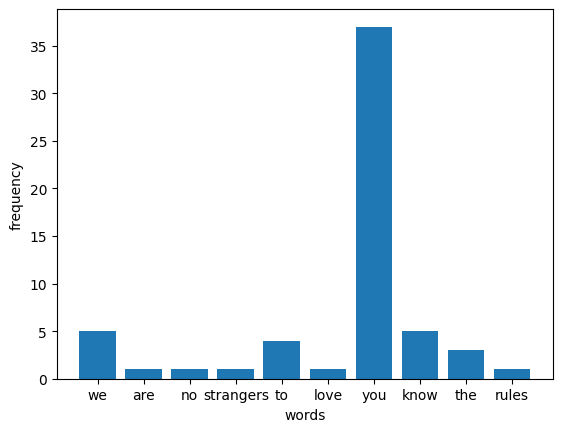

In [7]:
plt.bar(list(fdist.keys())[0:10], list(fdist.values())[0:10])
plt.xlabel("words")
plt.ylabel("frequency")
plt.show()

In [8]:
C = sum(fdist.values())
C

385

In [9]:
fdist['strangers']/C

0.0025974025974025974

In [10]:
vocabulary = set(tokens)

In [11]:
vocabulary

{'a',
 'aching',
 'and',
 'any',
 'are',
 'around',
 'ask',
 'been',
 'blind',
 'both',
 'but',
 'commitments',
 'cry',
 'desert',
 'do',
 'dont',
 'down',
 'each',
 'feeling',
 'for',
 'from',
 'full',
 'game',
 'get',
 'give',
 'going',
 'gon',
 'goodbye',
 'got',
 'guy',
 'hearts',
 'how',
 'hurt',
 'i',
 'if',
 'im',
 'inside',
 'it',
 'just',
 'know',
 'known',
 'let',
 'lie',
 'long',
 'love',
 'make',
 'me',
 'na',
 'never',
 'no',
 'of',
 'on',
 'other',
 'play',
 'rules',
 'run',
 'say',
 'see',
 'shy',
 'so',
 'strangers',
 'ta',
 'tell',
 'the',
 'thinking',
 'this',
 'to',
 'too',
 'understand',
 'up',
 'wan',
 'we',
 'were',
 'weve',
 'what',
 'whats',
 'wouldnt',
 'you',
 'your',
 'youre'}

In [12]:
bigrams = nltk.bigrams(tokens)
bigrams

<generator object bigrams at 0x00000175A73589E0>

In [13]:
my_bigrams = list(nltk.bigrams(tokens))
my_bigrams

[('we', 'are'),
 ('are', 'no'),
 ('no', 'strangers'),
 ('strangers', 'to'),
 ('to', 'love'),
 ('love', 'you'),
 ('you', 'know'),
 ('know', 'the'),
 ('the', 'rules'),
 ('rules', 'and'),
 ('and', 'so'),
 ('so', 'do'),
 ('do', 'i'),
 ('i', 'a'),
 ('a', 'full'),
 ('full', 'commitments'),
 ('commitments', 'what'),
 ('what', 'im'),
 ('im', 'thinking'),
 ('thinking', 'of'),
 ('of', 'you'),
 ('you', 'wouldnt'),
 ('wouldnt', 'get'),
 ('get', 'this'),
 ('this', 'from'),
 ('from', 'any'),
 ('any', 'other'),
 ('other', 'guy'),
 ('guy', 'i'),
 ('i', 'just'),
 ('just', 'wan'),
 ('wan', 'na'),
 ('na', 'tell'),
 ('tell', 'you'),
 ('you', 'how'),
 ('how', 'im'),
 ('im', 'feeling'),
 ('feeling', 'got'),
 ('got', 'ta'),
 ('ta', 'make'),
 ('make', 'you'),
 ('you', 'understand'),
 ('understand', 'never'),
 ('never', 'gon'),
 ('gon', 'na'),
 ('na', 'give'),
 ('give', 'you'),
 ('you', 'up'),
 ('up', 'never'),
 ('never', 'gon'),
 ('gon', 'na'),
 ('na', 'let'),
 ('let', 'you'),
 ('you', 'down'),
 ('down', 'nev

In [14]:
my_bigrams[0:10]

[('we', 'are'),
 ('are', 'no'),
 ('no', 'strangers'),
 ('strangers', 'to'),
 ('to', 'love'),
 ('love', 'you'),
 ('you', 'know'),
 ('know', 'the'),
 ('the', 'rules'),
 ('rules', 'and')]

In [15]:
frequency_bigrams = nltk.FreqDist(nltk.bigrams(tokens))
frequency_bigrams

FreqDist({('gon', 'na'): 38, ('never', 'gon'): 36, ('you', 'never'): 9, ('na', 'tell'): 8, ('make', 'you'): 8, ('na', 'give'): 6, ('give', 'you'): 6, ('you', 'up'): 6, ('up', 'never'): 6, ('na', 'let'): 6, ...})

In [16]:
frequency_bigrams[('we', 'are')]

1

In [17]:
for my_bigram in my_bigrams[0:10]:
    print(my_bigram)
    print(frequency_bigrams[my_bigram])

('we', 'are')
1
('are', 'no')
1
('no', 'strangers')
1
('strangers', 'to')
1
('to', 'love')
1
('love', 'you')
1
('you', 'know')
1
('know', 'the')
3
('the', 'rules')
1
('rules', 'and')
1


In [18]:
word = 'strangers'
vocab_probabilities = {}
for next_word in vocabulary:
    vocab_probabilities[next_word] = frequency_bigrams[(word, next_word)]/fdist[word]

vocab_probabilities

{'on': 0.0,
 'you': 0.0,
 'ta': 0.0,
 'are': 0.0,
 'get': 0.0,
 'me': 0.0,
 'the': 0.0,
 'blind': 0.0,
 'but': 0.0,
 'and': 0.0,
 'inside': 0.0,
 'give': 0.0,
 'love': 0.0,
 'from': 0.0,
 'strangers': 0.0,
 'shy': 0.0,
 'wouldnt': 0.0,
 'make': 0.0,
 'it': 0.0,
 'play': 0.0,
 'hearts': 0.0,
 'let': 0.0,
 'too': 0.0,
 'run': 0.0,
 'if': 0.0,
 'see': 0.0,
 'this': 0.0,
 'known': 0.0,
 'never': 0.0,
 'lie': 0.0,
 'hurt': 0.0,
 'game': 0.0,
 'a': 0.0,
 'full': 0.0,
 'rules': 0.0,
 'going': 0.0,
 'desert': 0.0,
 'feeling': 0.0,
 'goodbye': 0.0,
 'dont': 0.0,
 'youre': 0.0,
 'just': 0.0,
 'how': 0.0,
 'know': 0.0,
 'each': 0.0,
 'of': 0.0,
 'any': 0.0,
 'your': 0.0,
 'both': 0.0,
 'long': 0.0,
 'been': 0.0,
 'say': 0.0,
 'to': 1.0,
 'no': 0.0,
 'commitments': 0.0,
 'im': 0.0,
 'for': 0.0,
 'we': 0.0,
 'aching': 0.0,
 'around': 0.0,
 'cry': 0.0,
 'down': 0.0,
 'got': 0.0,
 'what': 0.0,
 'na': 0.0,
 'so': 0.0,
 'were': 0.0,
 'understand': 0.0,
 'tell': 0.0,
 'do': 0.0,
 'wan': 0.0,
 'whats': 0

In [19]:
vocab_probabilities = sorted(vocab_probabilities.items(), key=lambda x:x[1], reverse=True)
vocab_probabilities

[('to', 1.0),
 ('on', 0.0),
 ('you', 0.0),
 ('ta', 0.0),
 ('are', 0.0),
 ('get', 0.0),
 ('me', 0.0),
 ('the', 0.0),
 ('blind', 0.0),
 ('but', 0.0),
 ('and', 0.0),
 ('inside', 0.0),
 ('give', 0.0),
 ('love', 0.0),
 ('from', 0.0),
 ('strangers', 0.0),
 ('shy', 0.0),
 ('wouldnt', 0.0),
 ('make', 0.0),
 ('it', 0.0),
 ('play', 0.0),
 ('hearts', 0.0),
 ('let', 0.0),
 ('too', 0.0),
 ('run', 0.0),
 ('if', 0.0),
 ('see', 0.0),
 ('this', 0.0),
 ('known', 0.0),
 ('never', 0.0),
 ('lie', 0.0),
 ('hurt', 0.0),
 ('game', 0.0),
 ('a', 0.0),
 ('full', 0.0),
 ('rules', 0.0),
 ('going', 0.0),
 ('desert', 0.0),
 ('feeling', 0.0),
 ('goodbye', 0.0),
 ('dont', 0.0),
 ('youre', 0.0),
 ('just', 0.0),
 ('how', 0.0),
 ('know', 0.0),
 ('each', 0.0),
 ('of', 0.0),
 ('any', 0.0),
 ('your', 0.0),
 ('both', 0.0),
 ('long', 0.0),
 ('been', 0.0),
 ('say', 0.0),
 ('no', 0.0),
 ('commitments', 0.0),
 ('im', 0.0),
 ('for', 0.0),
 ('we', 0.0),
 ('aching', 0.0),
 ('around', 0.0),
 ('cry', 0.0),
 ('down', 0.0),
 ('got', 0.

In [23]:
def make_predictions(my_words, freq_grams, normalize=1, vocabulary=vocabulary):
    vocab_probabilities = {}
    context_size = len(list(freq_grams.keys())[0])
    my_tokens = preprocess(my_words)[0:context_size - 1]
    for next_word in vocabulary:
        temp = my_tokens.copy()
        temp.append(next_word)

        if normalize != 0:
            vocab_probabilities[next_word] = freq_grams[tuple(temp)] / normalize
        else:
            vocab_probabilities[next_word] = freq_grams[tuple(temp)]
    vocab_probabilities = sorted(vocab_probabilities.items(), key=lambda x: x[1], reverse=True)
    return vocab_probabilities

In [28]:
my_words="are"

vocab_probabilities=make_predictions(my_words,frequency_bigrams,normalize=fdist['are'])
vocab_probabilities

[('no', 1.0),
 ('on', 0.0),
 ('you', 0.0),
 ('ta', 0.0),
 ('are', 0.0),
 ('get', 0.0),
 ('me', 0.0),
 ('the', 0.0),
 ('blind', 0.0),
 ('but', 0.0),
 ('and', 0.0),
 ('inside', 0.0),
 ('give', 0.0),
 ('love', 0.0),
 ('from', 0.0),
 ('strangers', 0.0),
 ('shy', 0.0),
 ('wouldnt', 0.0),
 ('make', 0.0),
 ('it', 0.0),
 ('play', 0.0),
 ('hearts', 0.0),
 ('let', 0.0),
 ('too', 0.0),
 ('run', 0.0),
 ('if', 0.0),
 ('see', 0.0),
 ('this', 0.0),
 ('known', 0.0),
 ('never', 0.0),
 ('lie', 0.0),
 ('hurt', 0.0),
 ('game', 0.0),
 ('a', 0.0),
 ('full', 0.0),
 ('rules', 0.0),
 ('going', 0.0),
 ('desert', 0.0),
 ('feeling', 0.0),
 ('goodbye', 0.0),
 ('dont', 0.0),
 ('youre', 0.0),
 ('just', 0.0),
 ('how', 0.0),
 ('know', 0.0),
 ('each', 0.0),
 ('of', 0.0),
 ('any', 0.0),
 ('your', 0.0),
 ('both', 0.0),
 ('long', 0.0),
 ('been', 0.0),
 ('say', 0.0),
 ('to', 0.0),
 ('commitments', 0.0),
 ('im', 0.0),
 ('for', 0.0),
 ('we', 0.0),
 ('aching', 0.0),
 ('around', 0.0),
 ('cry', 0.0),
 ('down', 0.0),
 ('got', 0.

In [29]:
vocab_probabilities[0:10]

[('no', 1.0),
 ('on', 0.0),
 ('you', 0.0),
 ('ta', 0.0),
 ('are', 0.0),
 ('get', 0.0),
 ('me', 0.0),
 ('the', 0.0),
 ('blind', 0.0),
 ('but', 0.0)]

In [30]:
vocab_probabilities[0][0]

'no'

In [31]:
my_song=""
for w in tokens[0:100]:
  my_word=make_predictions(w,frequency_bigrams)[0][0]
  my_song+=" "+my_word
my_song

' know no strangers to say you never the game and hurt long i just lie commitments what im feeling of you never get this from any other for i just wan na tell a never im feeling got ta make you never never gon na tell you never never gon na tell you never never gon na tell around and hurt you never gon na tell you never never gon na tell goodbye never gon na tell a lie and hurt you never known each other for so long your hearts been going but youre too shy to say goodbye'

In [33]:
freq_trigrams  = nltk.FreqDist(nltk.trigrams(tokens))
freq_trigrams

FreqDist({('never', 'gon', 'na'): 36, ('you', 'never', 'gon'): 9, ('gon', 'na', 'give'): 6, ('na', 'give', 'you'): 6, ('give', 'you', 'up'): 6, ('you', 'up', 'never'): 6, ('up', 'never', 'gon'): 6, ('gon', 'na', 'let'): 6, ('na', 'let', 'you'): 6, ('let', 'you', 'down'): 6, ...})

In [34]:
make_predictions("so do",freq_trigrams,normalize=freq_trigrams[('do','i')] )[0:10]

[('i', 1),
 ('on', 0),
 ('you', 0),
 ('ta', 0),
 ('are', 0),
 ('get', 0),
 ('me', 0),
 ('the', 0),
 ('blind', 0),
 ('but', 0)]

In [35]:
my_song=""

w1=tokens[0]
for w2 in tokens[0:100]:
    gram=w1+' '+w2
    my_word=make_predictions(gram,freq_trigrams )[0][0]
    my_song+=" "+my_word
    w1=w2
my_song

' on no strangers to love you know the game and so do i a full commitments what im thinking of you wouldnt get this from any other guy i just wan na tell a how im feeling got ta make you cry never gon na give you up never gon na give you down never gon na give around and desert you never gon na give you cry never gon na give goodbye never gon na give a lie and hurt you never known each other for so long your hearts been aching but youre too shy to say it'